In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana2/snert/max/data/amigo_files/"
    data_path = "/media/morgana2/snert/max/data/JWST/IO/calslope/"
else:
    cache = "/Volumes/morgana2/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/IO/calslope/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/IO/")

state = np.load(
    os.path.join(model_cache, "ode/test_state.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [3]:
# Build the ramp model
n_latent = 6
keys = jr.split(jr.PRNGKey(0), 3)
encoder = amigo.latent_ode_models.LatentEncoder(
    n_latent=n_latent, width=6, depth=2, key=keys[0], pools=[0, 1]
)
latent_ode = amigo.latent_ode_models.LatentODE(
    n_latent=n_latent, width=3, depth=2, key=keys[1]
)
decoder = amigo.latent_ode_models.LatentDecoder(
    n_latent=n_latent, depth=3, key=keys[2], up_samples=[1, 2], out_channels=2
)

# ramp = LatentODERamp(encoder=encoder, latent_ode=latent_ode, decoder=decoder)
ode_ramp = amigo.latent_ode_models.GainDiffusionRamp(
    encoder=encoder, latent_ode=latent_ode, decoder=decoder
)

# Loading in data

In [4]:
files = file_fn(data_path)

# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
dorito.misc.truncate_files(sci_files, 18)

In [5]:
source_size = 120
level = 2
# shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
wavelets = dorito.wavelets.Wavelets(np.ones((source_size, source_size)), level=level)

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    [],
    # cal_files[0:3],
    sci_files[0:1],
    # cal_files,
    # sci_files,
    # [],
    state=state,
    modeller=dorito.models.WaveletModel,
    ramp_model=ode_ramp,
    extra_priors={
        "approx": wavelets.approx,
        "details": wavelets.values,
        # "log_distribution": np.log10(
        #     np.ones((source_size, source_size)) / source_size**2
        # ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    wavelets=wavelets,
    # shearletSystem=shearletSystem,
    sci_fit=dorito.model_fits.WaveletFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# init state
init_state = np.load(init_state_cache + "F430M.npy", allow_pickle=True)[()]
for p in [
    "positions",
    "fluxes",
    "aberrations",
    # "log_distribution",
]:
    params[p] = init_state[p]
model = model.set("params", params)

model = model.set("FF", np.ones_like(model.FF))

No Teff found for IO, defaulting to 4500K


/Users/mcha5804/miniconda3/envs/amigo/lib/python3.11/site-packages/astroquery/simbad/core.py:135: UserWarning: Warning: The script line number 2 raised an error (recorded in the `errors` attribute of the result table): 'IO': No known catalog could be found
  warnings.warn("Warning: The script line number %i raised "


In [6]:
fisher_params = [
    "positions",
    "fluxes",
    "aberrations",
    # "one_on_fs",
    # "log_distribution",
    "spectral_coeffs",
]

fishers = amigo.fisher.calc_fishers(
    model.set("ramp", None),
    fits,
    # sci_exposures,
    fisher_params,
    overwrite=True,
    cache=fisher_cache,
    recalculate=False,
)

  0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
def normalise_wavelets(model, model_params, args, key):
    params = model_params.params

    if "approx" not in params.keys() and "details" not in params.keys():
        return model_params, key

    for approx, details in zip(params["approx"].items(), params["details"].items()):

        k_a, approx = approx
        k_d, details = details

        wavelets = model.wavelets
        wavelets = wavelets.set(["approx", "values"], [approx, details])

        # normalising the wavelets so distribution adds to unity
        wavelets = wavelets.normalise()

        # setting the parameters to normalised versions
        params["approx"][k_a] = wavelets.approx
        params["details"][k_d] = wavelets.values

    return model_params.set("params", params), key

In [8]:
n_epoch = 100

config = {
    # "positions": sgd(2e-1, 0),
    # "fluxes": sgd(5e-1, 2),
    # "aberrations": sgd(5e-2, 4),
    # "log_distribution": adam(2e-2, 7),  # , (10, 0.25), b1=0.7),
    # "positions": sgd(2e-2, 5),
    "fluxes": sgd(2e-2, 0),
    # "log_distribution": adam(2e-2, 5),  # , (10, 0.25), b1=0.7),
    # "one_on_fs": sgd(1e2, 6),
    "approx": adam(5e-5, 0),
    "details": adam(5e-5, 0),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    "L1": 1.0e-3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e-3,
    # "ME": None,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        "L1": dorito.stats.L1_on_wavelets,
        "QV": dorito.stats.TSV,
        "ME": dorito.stats.ME,
    },
}

final_model, losses, state, histories = amigo.fitting.optimise(
    model,
    # pds_sci_exposures,
    fits,
    fishers=fishers,
    optimisers=config,
    args=args,
    # norm_fn=dorito.stats.normalise_wavelets,
    norm_fn=normalise_wavelets,
    # norm_fn=dorito.stats.normalise_distribution,
    loss_fn=dorito.stats.regularised_loss_fn,
    epochs=n_epoch,
    print_grads=False,
)

# balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
# print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/100 [00:00<?, ?it/s]

Grad Batch fn compiling...
Compiling update function
Grad Batch fn compiling...
Compiling update function
Compile Time: 0:00:04
Initial Loss: 30,009.65
Est time per epoch:  0:00:00
Est run time:  0:01:28
Full Time: 0:01:29
Final Loss: 17,510.75


In [9]:
def level2_plot(coeffs):
    # Extract the decomposition coefficients
    ll2, (hl2, lh2, hh2), (hl1, lh1, hh1) = coeffs

    # Plotting corner plot visualization
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    titles = [
        "Approximation (LL2)",
        "Horizontal (HL2)",
        "Vertical (LH2)",
        "Diagonal (HH2)",
        "Horizontal (HL1)",
        "Vertical (LH1)",
        "Diagonal (HH1)",
    ]

    coeff_plots = [ll2, hl2, lh2, hh2, hl1, lh1, hh1]
    positions = [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3)]

    # Plot each coefficient sub-band
    for (i, j), coeff, title in zip(positions, coeff_plots, titles):
        ax = axes[i, j]
        c = ax.imshow(coeff.squeeze(), cmap="seismic")
        ax.set_title(title + f", sum: {coeff.sum():.2e}")
        # ax.axis("off")
        fig.colorbar(
            c,
            ax=ax,
        )

    axes[1, 0].axis("off")  # Hide unused subplot
    plt.tight_layout()
    plt.show()

!


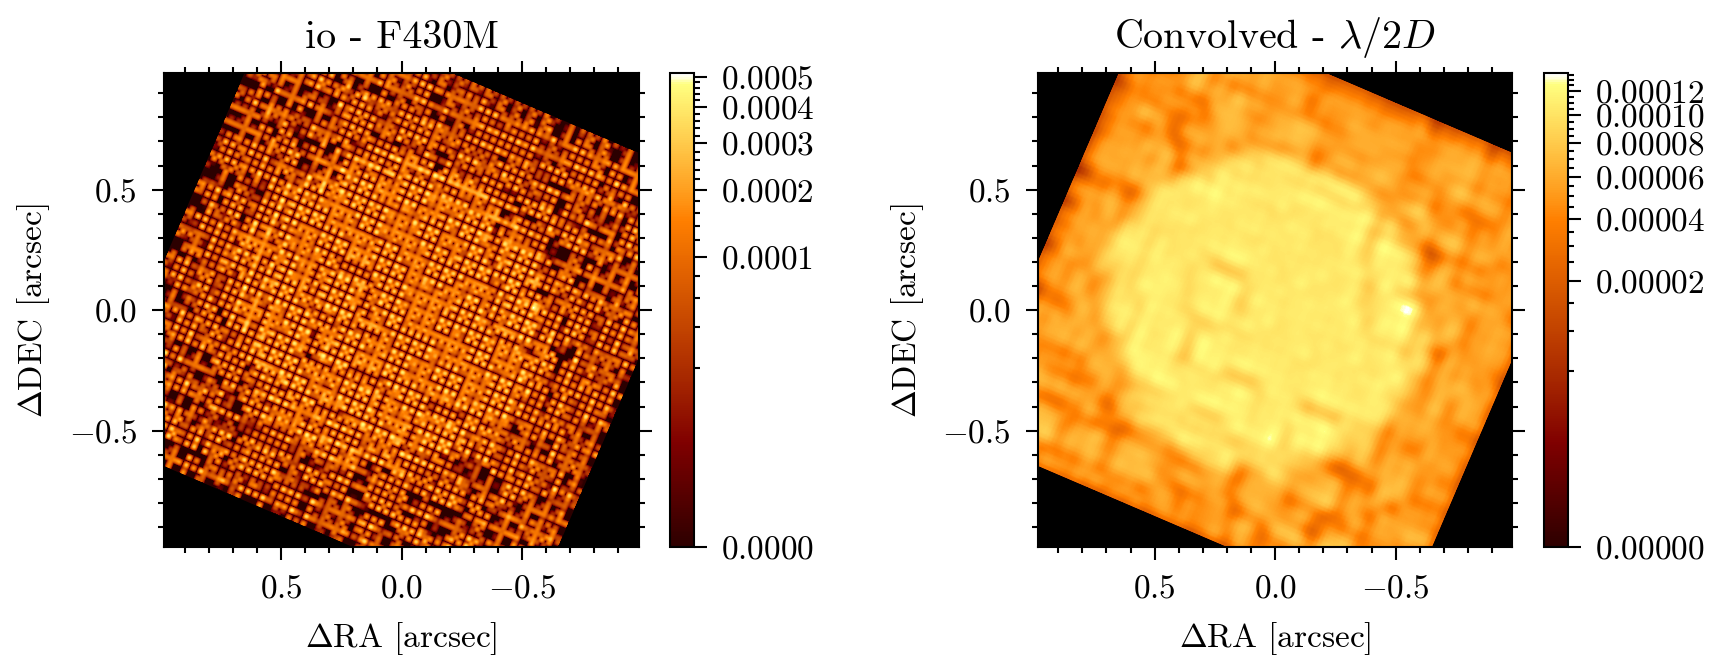

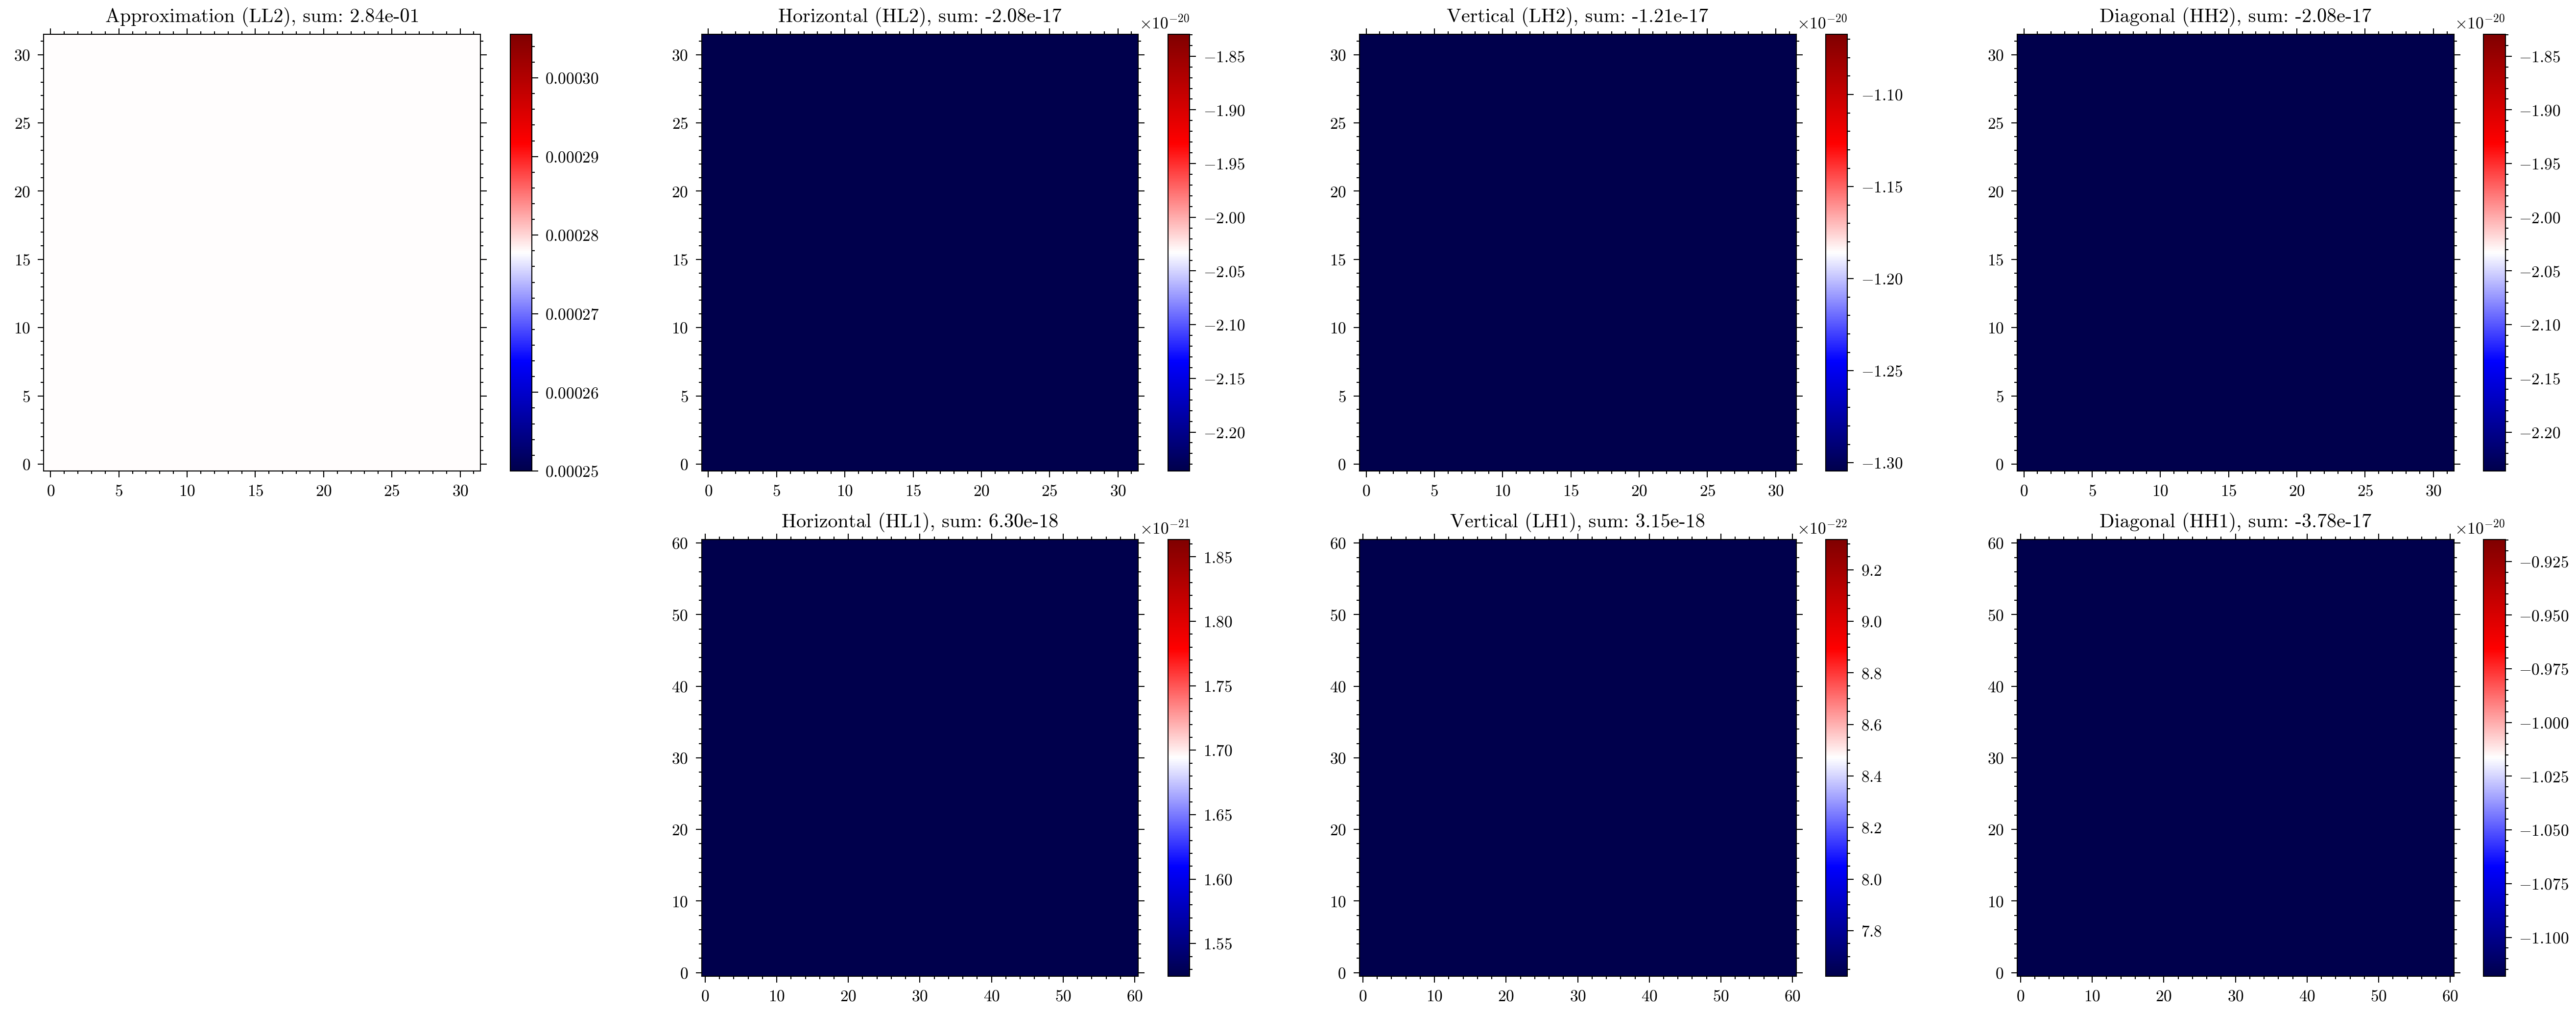

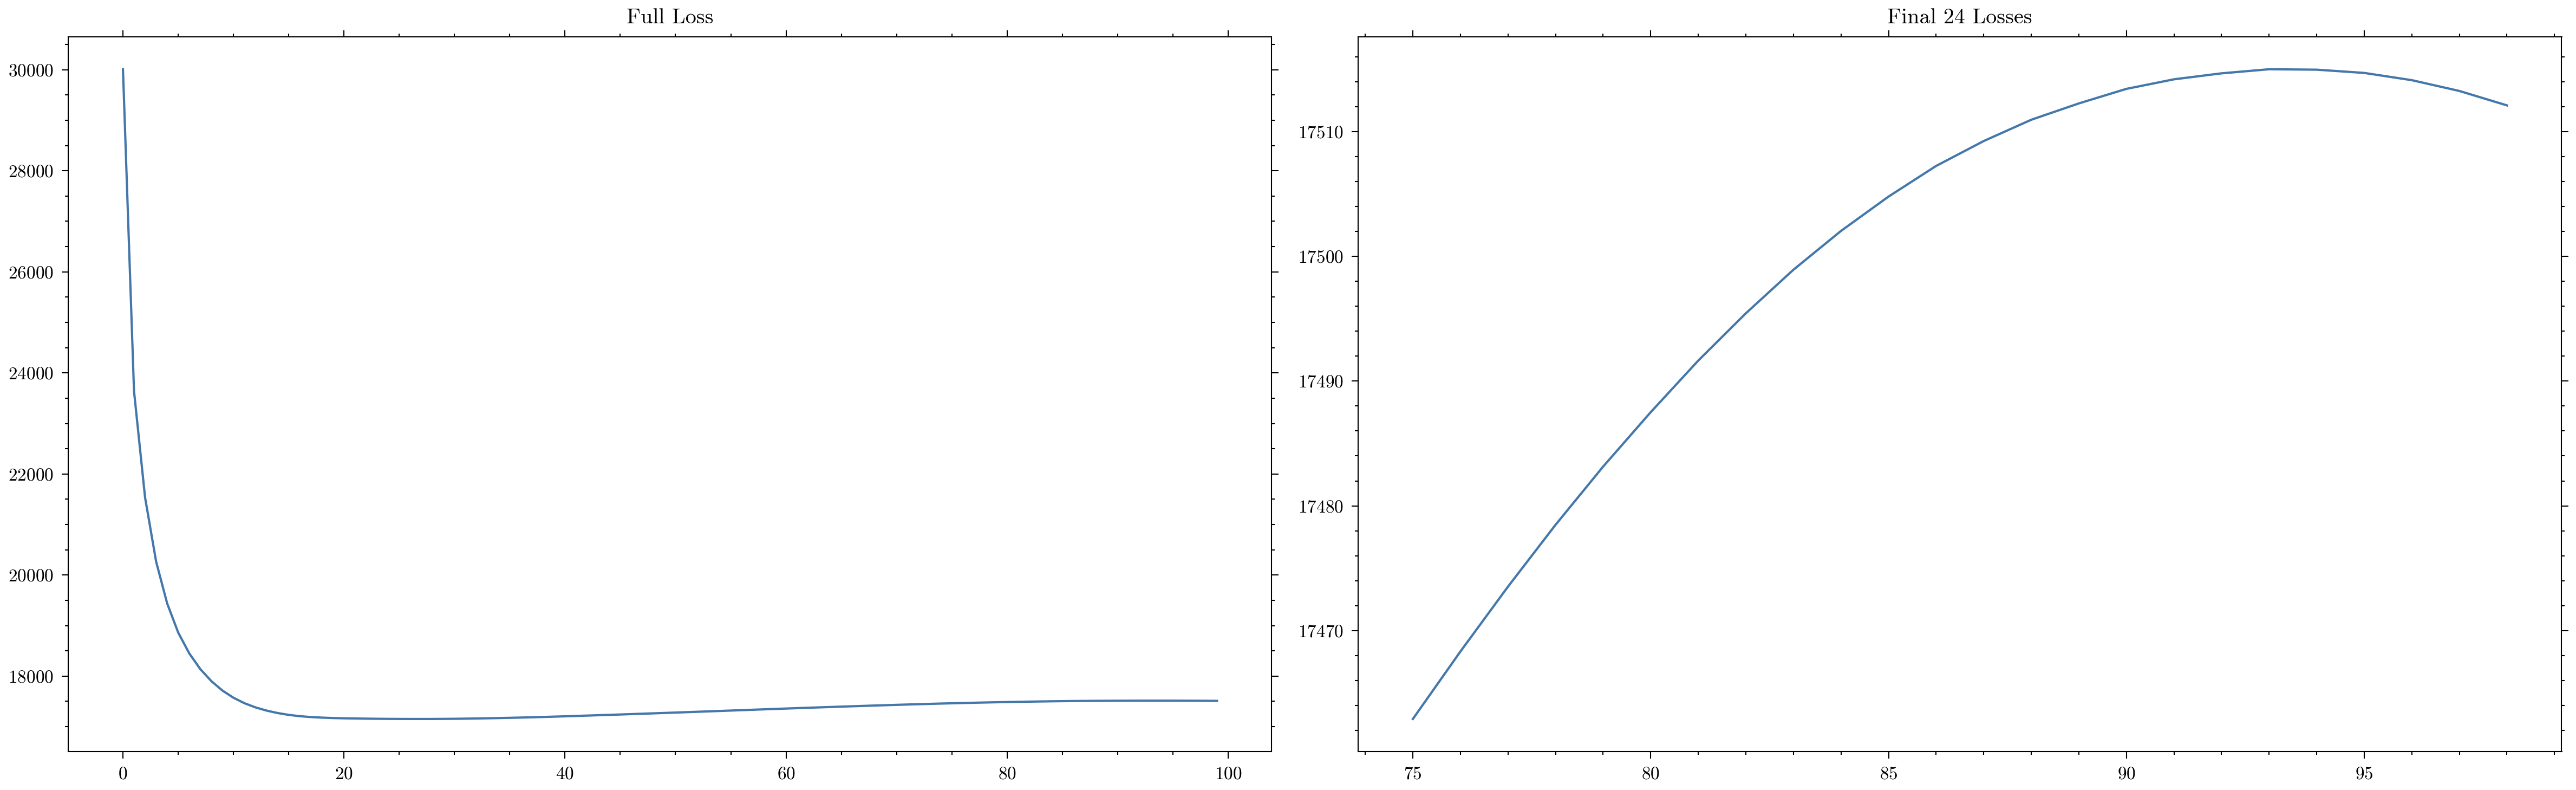

No formatting function for approx
No formatting function for details


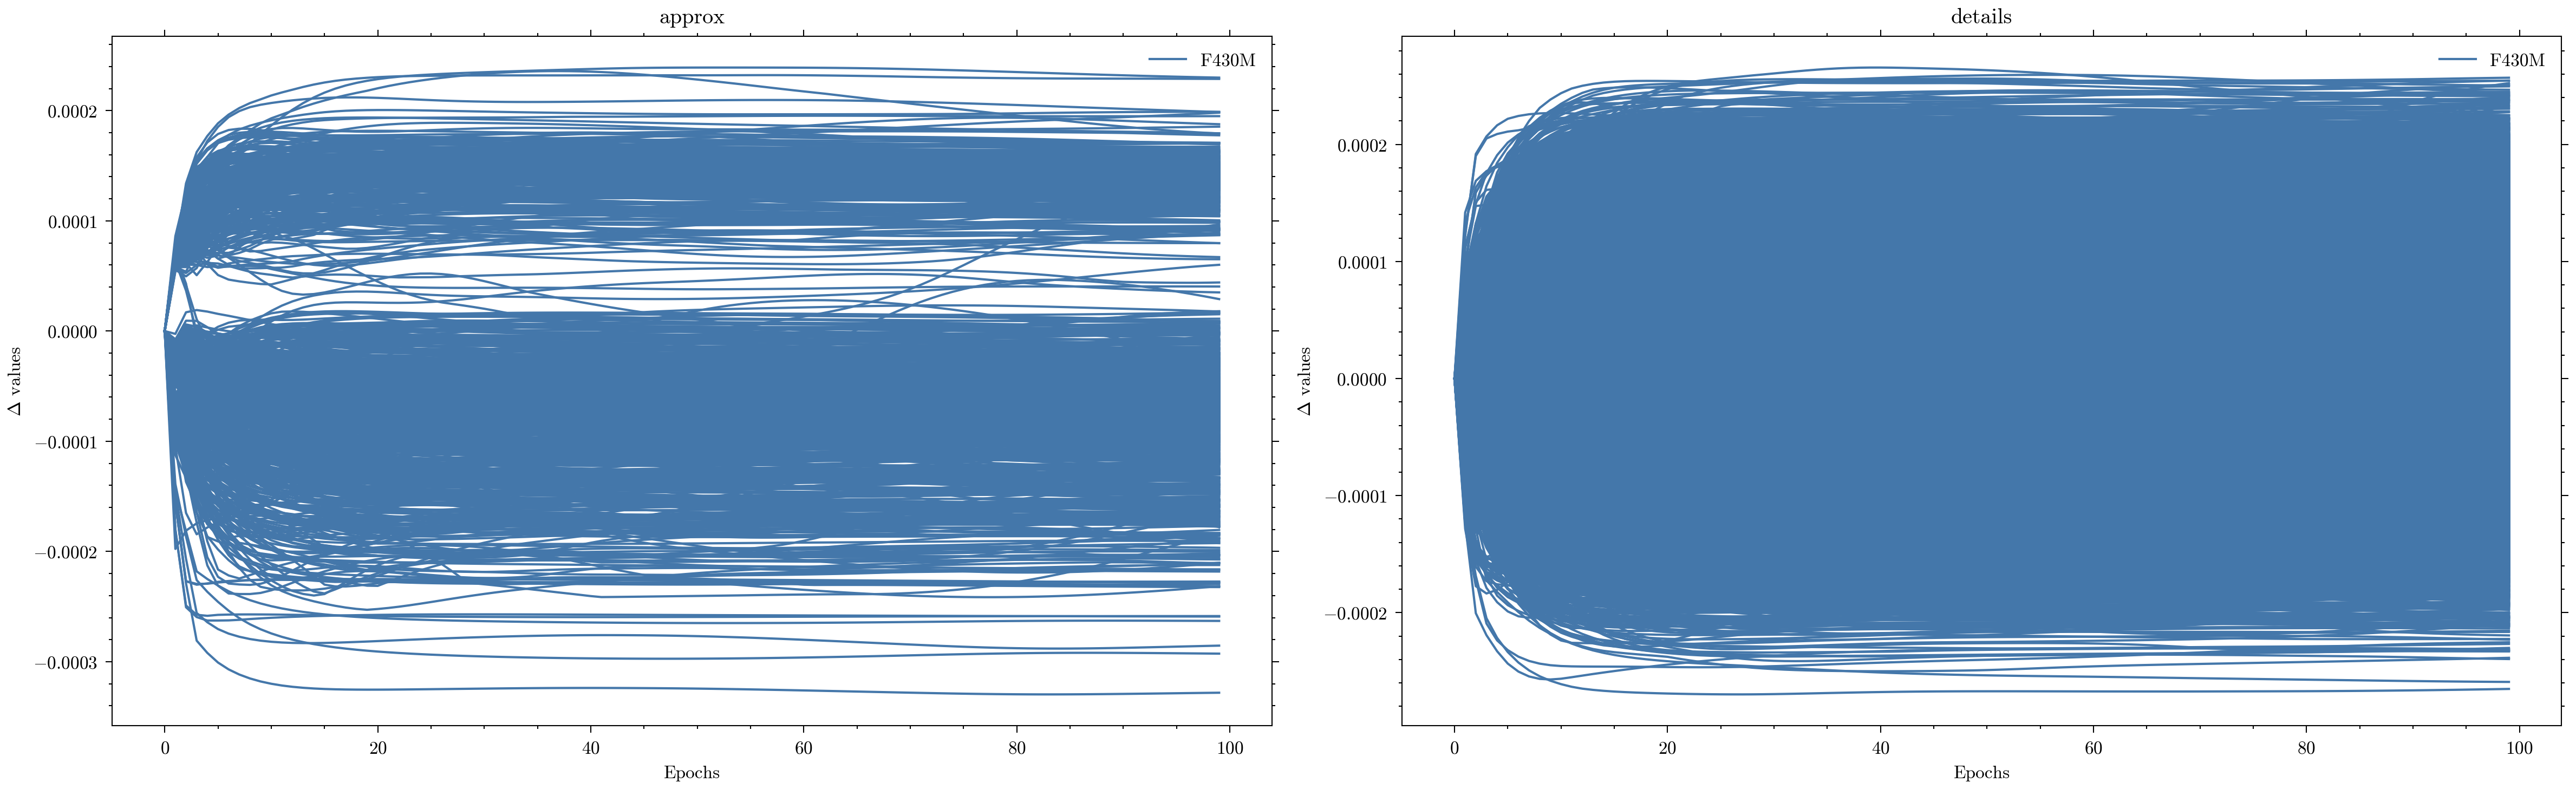

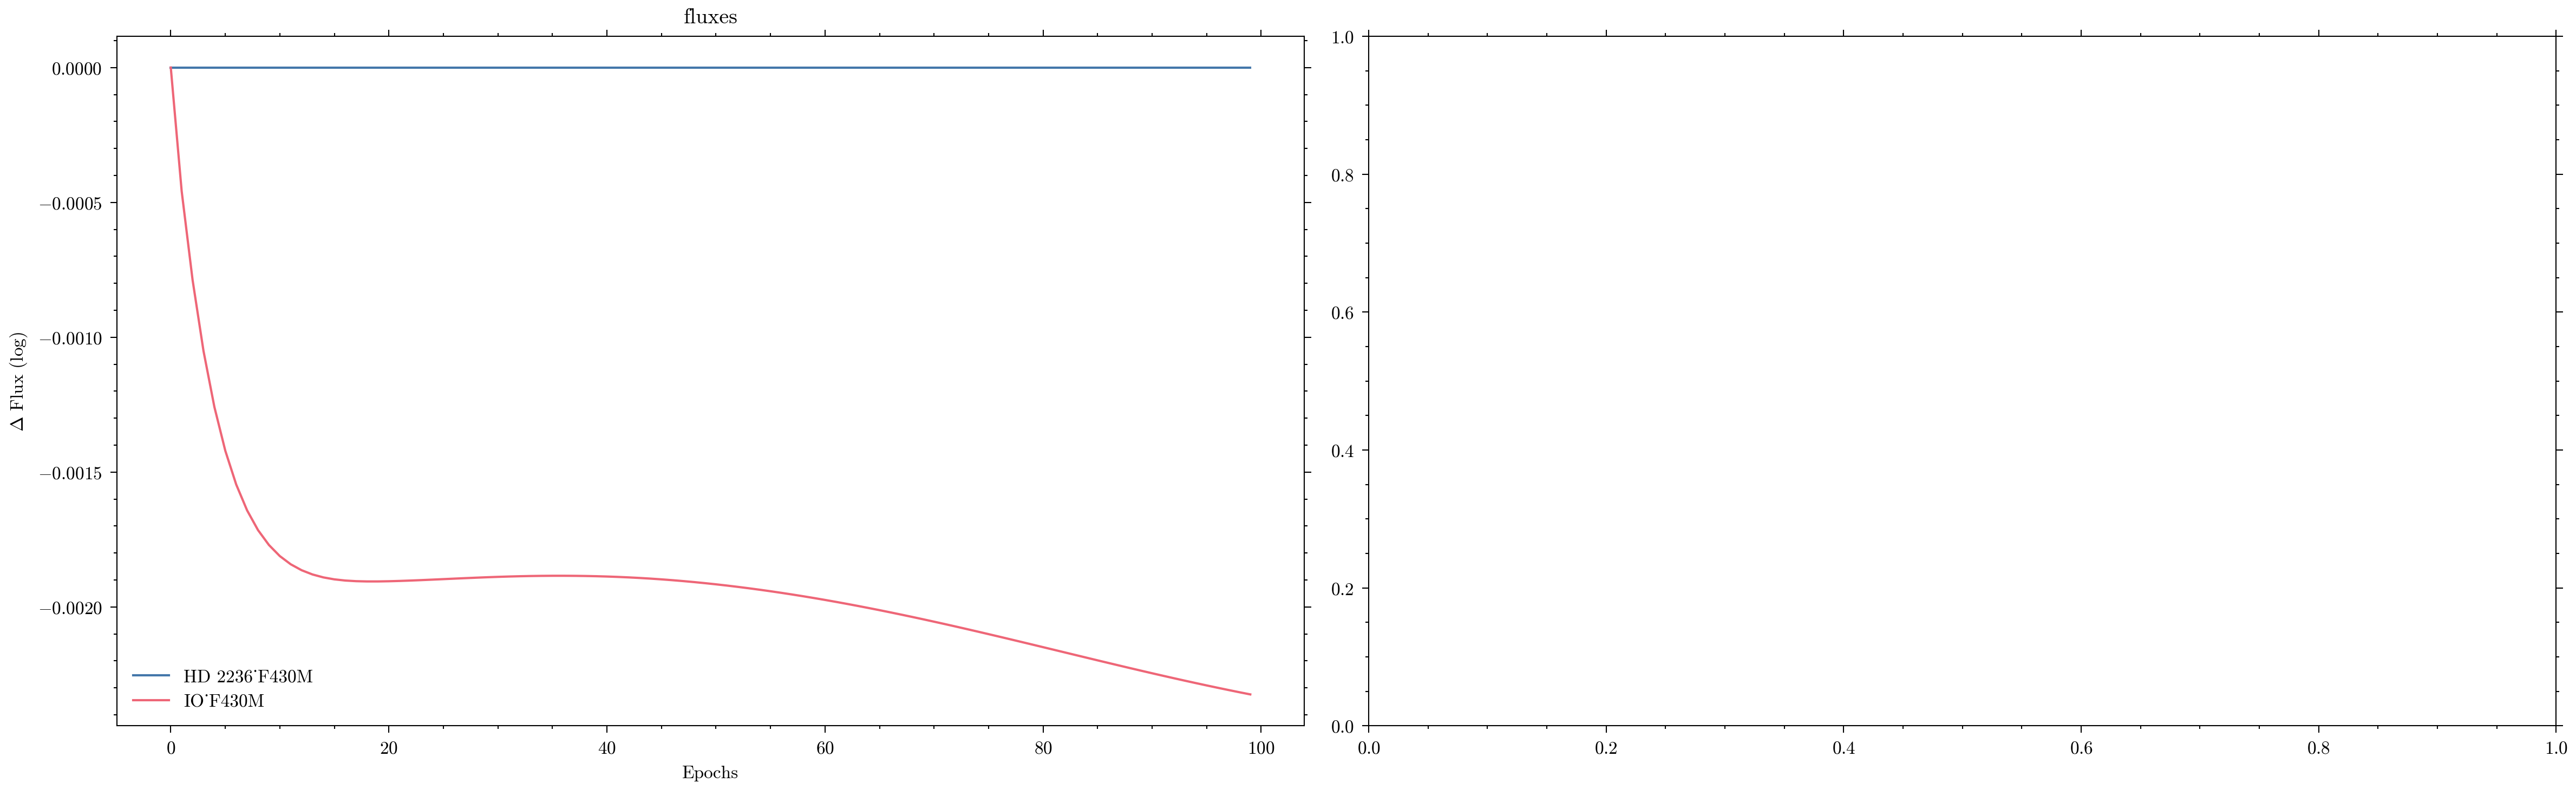

File 01373_017_02_04_3
Star IO
Filter F430M
nints 100
ngroups 18



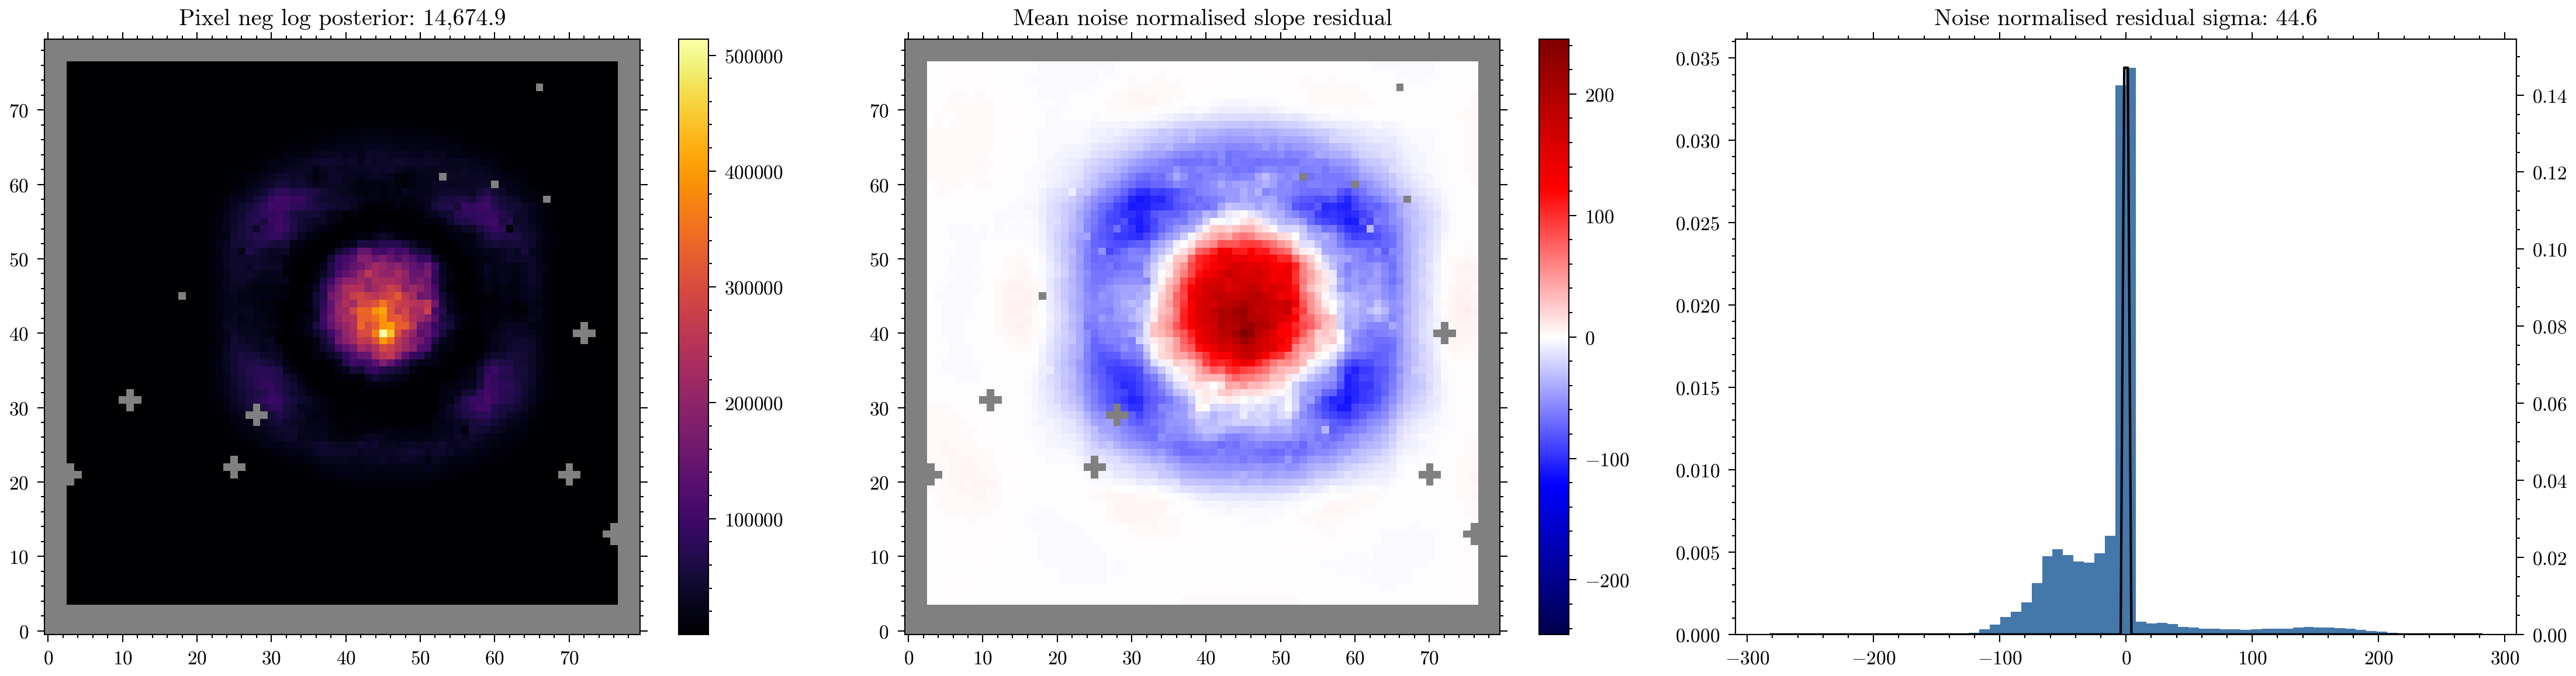

In [11]:
# np.save(init_state_cache + "F430M.npy", state.params)

flag = False
for exp in fits:

    try:
        if not flag:
            print("!")
            try:
                dist = final_model.get_distribution(exp)
            except:
                dist = exp.get_distribution(final_model)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                # model=final_model,
                vmin=None,
                # show_diff_lim=True,
                # vmax=io_peak_flux,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, final_model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            ax[0].set_title(f"io - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(save_dir + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        # flag = True
    except:
        continue

level2_plot([final_model.wavelets.approx, *final_model.wavelets.build])

amigo.plotting.plot_losses(losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(histories)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        final_model,
        exp,
        # test_model,
    )

In [ ]:
def level2_plot(coeffs):
    # Extract the decomposition coefficients
    ll2, (hl2, lh2, hh2), (hl1, lh1, hh1) = coeffs

    # Plotting corner plot visualization
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    titles = [
        "Approximation (LL2)",
        "Horizontal (HL2)",
        "Vertical (LH2)",
        "Diagonal (HH2)",
        "Horizontal (HL1)",
        "Vertical (LH1)",
        "Diagonal (HH1)",
    ]

    coeff_plots = [ll2, hl2, lh2, hh2, hl1, lh1, hh1]
    positions = [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3)]

    # Plot each coefficient sub-band
    for (i, j), coeff, title in zip(positions, coeff_plots, titles):
        ax = axes[i, j]
        c = ax.imshow(np.abs(coeff).squeeze(), cmap="viridis")
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(
            c,
            ax=ax,
        )

    axes[1, 0].axis("off")  # Hide unused subplot
    plt.tight_layout()
    plt.show()

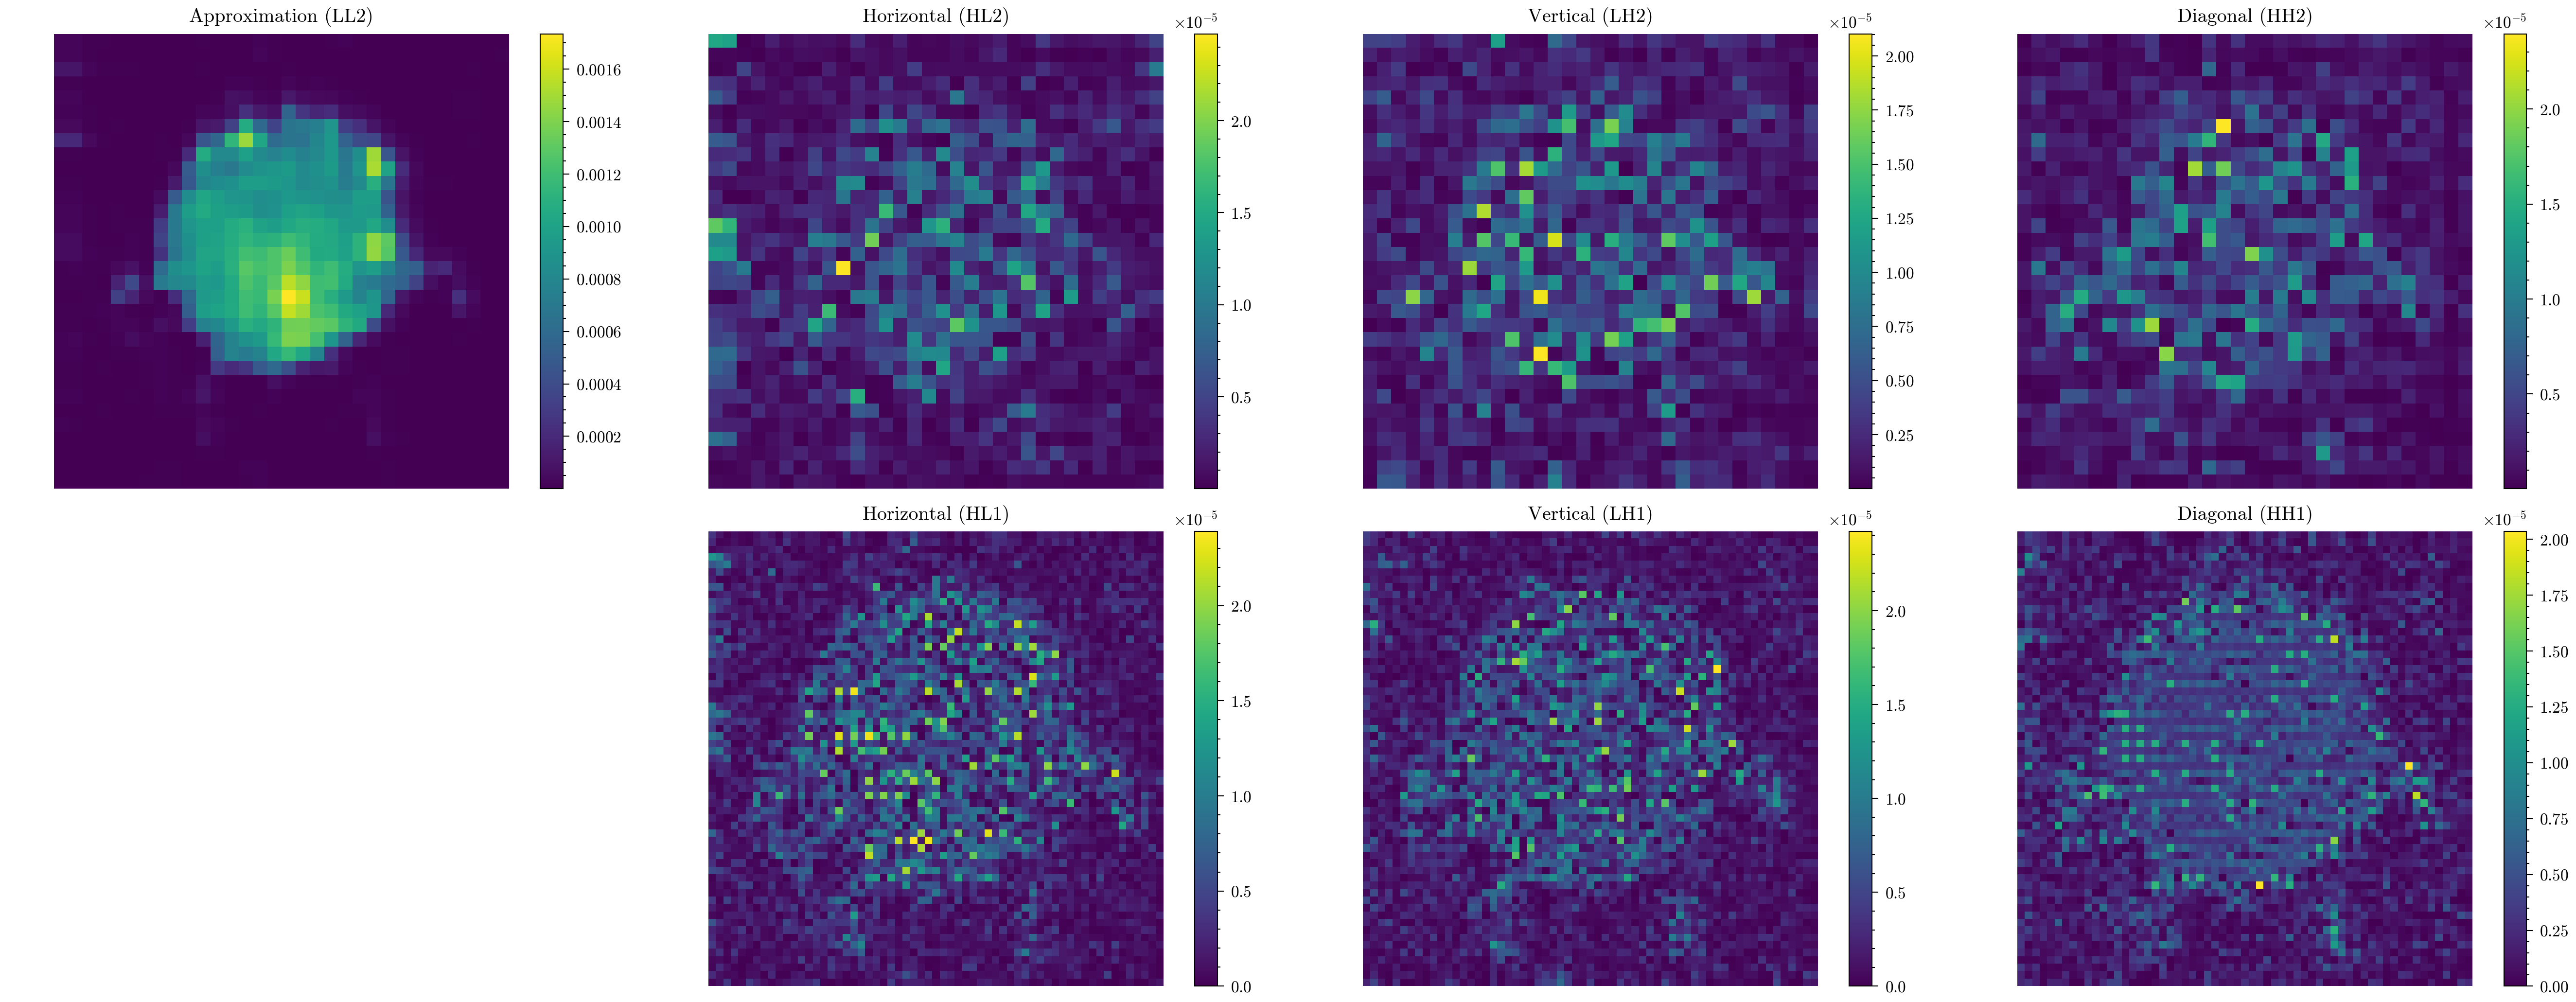

In [ ]:
level2_plot(final_model._wavelet_coeffs_from_key("F430M"))

In [ ]:
import jaxwt
from scipy.datasets import ascent


coeffs = jaxwt.conv_fwt_2d.wavedec2(
    ascent(),
    "db2",
    level=2,
)

In [ ]:
x = coeffs[0]
y = coeffs[1:]